In [267]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px
from typing import Optional


In [4]:
from treasury_ml_utils.snowflake_utils import SnowflakeConnector

snowflake_client = SnowflakeConnector("joshua.choy@transferwise.com")

Initiating login request with your identity provider. A browser window should have opened for you to complete the login. If you can't see it, check existing browser windows, or your OS settings. Press CTRL+C to abort and try again...
Going to open: https://transferwise.okta-emea.com/app/snowflake/exk4istpb5gZUyV8u0i7/sso/saml?SAMLRequest=nVLBbuIwEP2VyHtOnIRAwQIqWoSWinYpBFbiZpIBLBI79TgE%2Fn4dAqvuoT2s5INlv5n3Zt7rP57zzDmBRqHkgASeTxyQiUqF3A%2FIKp64XeKg4TLlmZIwIBdA8jjsI8%2Bzgo1Kc5AL%2BCgBjWMbSWT1x4CUWjLFUSCTPAdkJmHL0euMhZ7POCJoY%2BnIrSRFYbkOxhSM0qqqvKrlKb2noe%2F71O9Ri6ohP8gniuJ7jkIroxKV3UvOdqYvKALqRzWFRViG%2Ba3wSchmBd%2BxbBsQsp9xPHfnv5YxcUb36Z6VxDIHvQR9EgmsFrNGAFoFizh8iMKuB6WbgDSaZ27goVTVLuNHSFRelMY29uyN7iClmdoLu67peECKo0hVEmG17U3eX4%2Bnp%2BCwPcjO5n0yW798BIXaF1H4O44WW3GGl25CnPXd3LA2d4pYwlTWlhr75Icd1w%2Ftif2QtQPWbnmdXmtDnLG1VEhurpV33VapxB3oSiB46mi4Cznwq0xeFPTvBBTOx0igKbbt%2FWZ1WXdLXzxQREVr70gTH3aVoof%2FsZQ%2B%2FdzgFsY36890PFeZSC7OROmcm6%2FtC7zg%2BiJSd3eFMsi5yEZpqgHR2phlqnrWwI3NvNElEDpsWP9N%2

In [5]:
pnl_df = snowflake_client.fetch(

'''
select HOUR_TIMESTAMP, ccy, sum(FX_PNL) as total_fx_pnl
from RPT_TREASURY.TREASURY_FX_PNL_HOURLY
where ccy in ('MYR', 'PHP', 'INR', 'IDR', 'KRW', 'THB', 'VND')
and HOUR_TIMESTAMP::date >= '2024-01-01'
group by all

'''
)

exposure_df = snowflake_client.fetch(
'''
with position as
(SELECT ccy
    , case
          when minute(created_at) > 30
              then time_slice(created_at, 1, 'hour', 'end')
          else time_slice(created_at, 1, 'hour', 'start') end
             as hour_timestamp
    , sum(amount) as hour_position
FROM ARM.OPEN_POSITION_AUDIT
WHERE TYPE IN ('CUSTOMER',
              'BORDERLESS',
              'HEDGE')
 AND hour_timestamp >= '2024-01-01'
and ccy in ('THB','MYR', 'PHP', 'INR', 'IDR', 'KRW', 'THB', 'VND')
group by all),

rates as (
    select MINUTE_TIMESTAMP, target_ccy, SOURCE_CCY, value
    from RATE_HISTORICAL.ANALYTICS_RATES
    where TARGET_CCY in ('GBP', 'USD')
    and minute_timestamp >= '2024-01-01')

select position.*,
       rates_usd.value as rate_to_usd,
       rates_gbp.value as rate_to_gbp
from position
left join rates as rates_usd
    on rates_usd.MINUTE_TIMESTAMP = hour_timestamp
    and rates_usd.TARGET_CCY = 'USD'
    and rates_usd.SOURCE_CCY = position.ccy
left join rates as rates_gbp
    on rates_gbp.MINUTE_TIMESTAMP = hour_timestamp
    and rates_gbp.TARGET_CCY = 'GBP'
    and rates_gbp.SOURCE_CCY = position.ccy
'''

)

In [6]:
pnl_df

,hour_timestamp,ccy,total_fx_pnl
0,2025-12-25 09:00:00,IDR,-58.177039
1,2025-12-25 01:00:00,INR,-7263.289310
2,2025-12-24 15:00:00,KRW,4143.055516
3,2025-12-24 14:00:00,KRW,-3157.923711
4,2025-12-23 07:00:00,IDR,-5539.964134
...,...,...,...
128200,2026-01-24 19:00:00,IDR,14.412179
128201,2026-01-24 19:00:00,INR,-260.575254
128202,2026-01-22 04:00:00,PHP,7626.503380
128203,2026-01-22 02:00:00,IDR,-6140.927422


In [7]:
#pnl_df = pd.read_csv('/Users/joshua.choy/Downloads/total_fx_pnl_2024_onwards.csv')
# exposure_df = pd.read_csv('/Users/joshua.choy/Downloads/exposure_2024_onwards.csv')

pnl_df['hour_timestamp'] = pd.to_datetime(pnl_df['hour_timestamp'])
exposure_df['hour_timestamp'] = pd.to_datetime(exposure_df['hour_timestamp'])

In [8]:
print(exposure_df.columns)
print(pnl_df.columns)

Index(['ccy', 'hour_timestamp', 'hour_position', 'rate_to_usd', 'rate_to_gbp'], dtype='object')
Index(['hour_timestamp', 'ccy', 'total_fx_pnl'], dtype='object')


In [62]:
sorted_pnl = pnl_df.sort_values(by=['hour_timestamp'])
sorted_exposure = exposure_df.sort_values(by=['hour_timestamp'])
df = pd.merge(exposure_df, pnl_df[['hour_timestamp', 'ccy', 'total_fx_pnl']], on=["hour_timestamp", 'ccy'], how='left')
df['usd_rate'] = 1/df['rate_to_usd']
df['gbp_rate'] = 1/df['rate_to_gbp']
df['position_in_USD'] = df['hour_position'] / df['usd_rate']
df['position_in_GBP'] = df['hour_position'] / df['gbp_rate']
df.head()

,ccy,hour_timestamp,hour_position,rate_to_usd,rate_to_gbp,total_fx_pnl,usd_rate,gbp_rate,position_in_USD,position_in_GBP
0,THB,2024-02-15 20:00:00,1.309710e+07,0.027728,0.022011,24.778688,36.064498,45.432242,3.631577e+05,2.882777e+05
1,KRW,2024-02-09 12:00:00,6.208406e+09,0.000751,0.000596,-1219.079264,1331.557923,1678.697331,4.662513e+06,3.698347e+06
2,INR,2024-02-09 12:00:00,3.318016e+09,0.012044,0.009553,11887.662008,83.025447,104.674775,3.996384e+07,3.169833e+07
3,KRW,2024-02-15 19:00:00,9.479931e+08,0.000751,0.000596,-96.547312,1331.557923,1676.727029,7.119428e+05,5.653831e+05
4,VND,2024-02-15 19:00:00,-3.133371e+10,0.000041,0.000032,-56.772561,24449.877751,30769.230769,-1.281549e+06,-1.018346e+06


In [271]:
def filter_df(df, day_of_week:int, hour_of_day:int, ccy: Optional[str] = None):
    '''
    :param df: dataframe of exposure data
    :param day_of_week: int to represent day of week, Mon = 0 and Sun = 6
    :param hour_of_day: hour of day in UTC
    :param ccy: (Optional) ccy code in string format (e.g 'VND')
    '''
    mask = (
        (df['hour_timestamp'].dt.dayofweek == day_of_week) & 
        (df['hour_timestamp'].dt.hour == hour_of_day) 
        #(df['ccy'] == ccy )
    )

    if ccy is not None:
        mask = mask & (df['ccy'] == ccy)

    return df.loc[mask].sort_values(by='hour_timestamp')

In [96]:
def calc_statistics(df, ccy:str):
    '''
    :param df: dataframe to calculate on
    :param ccy: string of ccy that we are measuring on
    '''

    ccy_df = df.loc[df['ccy'] == ccy]
    ccy_stats  = ccy_df.groupby('ccy').agg(
        avg_usd_exposure = ('position_in_USD', 'mean'),
        sd_exposure = ('position_in_USD', 'std'),
        avg_pnl = ('total_fx_pnl', 'mean'),
        worst_loss = ('total_fx_pnl', 'min'),
        sd_pnl = ('total_fx_pnl', 'std')

    )

    return ccy_stats


In [67]:
monday_df = filter_df(df, 0, 0)
monday_df['abs_position_USD'] = monday_df['position_in_USD'].abs()
monday_df.sort_values('abs_position_USD', ascending=False).head()

/var/folders/r6/lyd4620542j8pdy7dl_ccjtw0000gp/T/ipykernel_60409/4035449270.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  monday_df['abs_position_USD'] = monday_df['position_in_USD'].abs()


,ccy,hour_timestamp,hour_position,rate_to_usd,rate_to_gbp,total_fx_pnl,usd_rate,gbp_rate,position_in_USD,position_in_GBP,abs_position_USD
118774,INR,2025-09-01,-4.109559e+09,0.011341,0.008399,41196.473389,88.174091,119.066046,-4.660733e+07,-3.451495e+07,4.660733e+07
7808,IDR,2025-03-31,7.641236e+11,0.000060,0.000047,-76352.894004,16556.291391,21413.276231,4.615306e+07,3.568457e+07,4.615306e+07
110682,PHP,2025-12-08,2.508880e+09,0.016958,0.012726,-16444.894062,58.969566,78.579904,4.254534e+07,3.192776e+07,4.254534e+07
82478,INR,2026-01-26,-3.854437e+09,0.010908,0.007983,8888.483584,91.674994,125.259914,-4.204459e+07,-3.077152e+07,4.204459e+07
87366,THB,2025-10-20,-1.317174e+09,0.030465,0.022692,5168.697382,32.824984,44.069171,-4.012719e+07,-2.988879e+07,4.012719e+07


In [192]:
def scatterplot(df, day_of_week:int, hour_of_day:int):
    '''
    :param: df: dataframe containing snap data from grafana
    :day_of_week: integer of day, 0 = Monday
    :hour_of_day: integer of hour, 0 = midnight UTC
    '''

    filtered_df = filter_df(df, day_of_week=day_of_week, hour_of_day=hour_of_day)
    plt.figure(figsize=(12, 6))

    # Plotting only the Monday 8am Slice
    sns.scatterplot(
        data=filtered_df,
        x='position_in_USD', # Use signed position to see Direction (Long/Short)
        y='total_fx_pnl',
        hue='ccy',           # Color by currency     # Dot size = Size of the PnL impact
        sizes=(50, 400),
        alpha=0.75
    )

    day_dict = {0:'Monday', 1: "Tuesday", 2:"Wednesday", 3:"Thursday", 4:"Friday"}

    plt.title(f'{day_dict[day_of_week]} {hour_of_day + 8} SGP: Exposure vs. PnL Impact')
    plt.xlabel('Position in USD (Left=Short, Right=Long)')
    plt.ylabel('Total FX PnL')
    plt.axhline(0, color='black', linewidth=1) # Zero PnL line
    plt.axvline(0, color='black', linewidth=1) # Zero Position line
    plt.grid(True, linestyle='--', alpha=0.5)
    
    return plt.show()


def scatterplot_interactive(df, day_of_week:int, hour_of_day:int):
    '''
    :param: df: dataframe containing snap data from grafana
    :day_of_week: integer of day, 0 = Monday
    :hour_of_day: integer of hour, 0 = midnight UTC
    '''

    df['hour_timestamp'] = pd.to_datetime(df['hour_timestamp'])
    filtered_df = filter_df(df, day_of_week=day_of_week, hour_of_day=hour_of_day)
    filtered_df['date_str'] = filtered_df['hour_timestamp'].dt.strftime('%Y-%m-%d')

    day_dict = {0:'Monday', 1: "Tuesday", 2:"Wednesday", 3:"Thursday", 4:"Friday"}

    fig = px.scatter(
    filtered_df,
    x='position_in_USD',
    y='total_fx_pnl',
    color='ccy',                 # Different color per currency
    size=filtered_df['total_fx_pnl'].abs(), # Bubble size based on PnL magnitude
    hover_name='ccy',            # Title of the tooltip
    hover_data={                 # Customizing what shows up when you hover
        'date_str': True,
        'position_in_USD': ':,.0f', # Format with commas
        'total_fx_pnl': ':,.2f',    # Format with 2 decimals
        'usd_rate': ':.6f',      # Show the rate used
        'ccy': False,               # Already in title
        'hour_timestamp': False     # Replaced by date_str
    },
    title=f'{day_dict[day_of_week]} {hour_of_day+8} SGP Exposure vs. PnL Impact',
    template='plotly_white',      # Clean background
    height=600                    # Taller chart
)

    fig.add_hline(y=0, line_width=1, line_dash="solid", line_color="black", opacity=0.5)
    fig.add_vline(x=0, line_width=1, line_dash="solid", line_color="black", opacity=0.5)
    return fig.show()

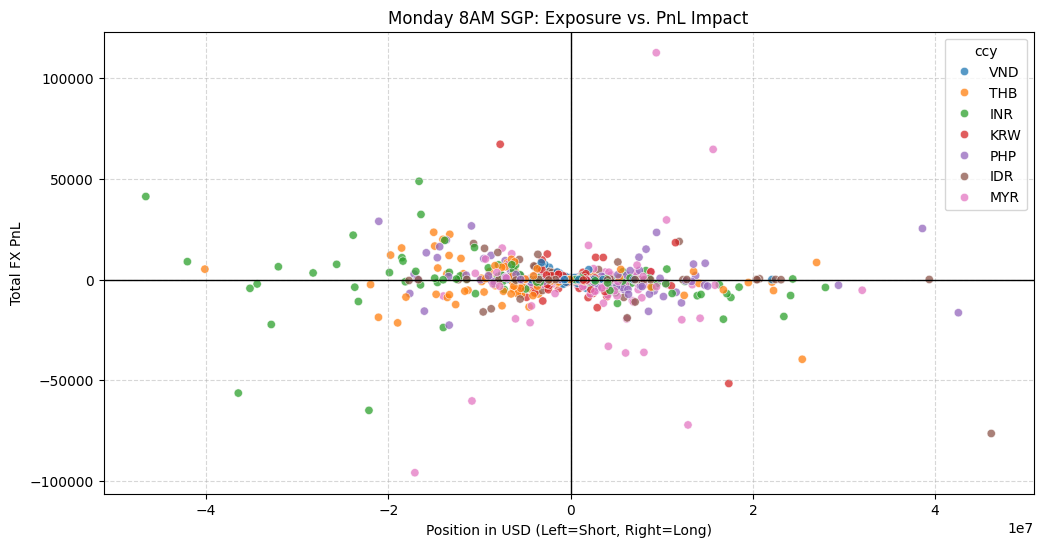

In [166]:
scatterplot(df, 0, 0)

In [205]:
scatterplot_interactive(df, 0, 0)

/var/folders/r6/lyd4620542j8pdy7dl_ccjtw0000gp/T/ipykernel_60409/1927043220.py:42: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [273]:
filter_df(df, 0, 0, 'PHP')

,ccy,hour_timestamp,hour_position,rate_to_usd,rate_to_gbp,total_fx_pnl,usd_rate,gbp_rate,position_in_USD,position_in_GBP
103058,PHP,2024-01-01,7.353256e+08,0.018055,0.014182,-934.758220,55.387547,70.513905,1.327601e+07,1.042809e+07
28549,PHP,2024-01-08,7.627994e+07,0.017994,0.014149,-434.044353,55.575007,70.674874,1.372558e+06,1.079308e+06
36216,PHP,2024-01-15,-1.026373e+08,0.017878,0.014038,412.684690,55.934043,71.234711,-1.834971e+06,-1.440833e+06
4658,PHP,2024-01-22,5.913751e+06,0.017868,0.014071,90.136368,55.964720,71.069670,1.056693e+05,8.321061e+04
32146,PHP,2024-01-29,4.763163e+07,0.017755,0.013984,-297.935110,56.322480,71.509786,8.456948e+05,6.660854e+05
...,...,...,...,...,...,...,...,...,...,...
62737,PHP,2026-01-05,4.588378e+07,0.016994,0.012646,-119.227706,58.842913,79.076388,7.797673e+05,5.802463e+05
90829,PHP,2026-01-12,-6.447571e+08,0.016874,0.012599,26614.493604,59.262069,79.372639,-1.087976e+07,-8.123166e+06
70699,PHP,2026-01-19,-1.167216e+08,0.016831,0.012559,-53.670973,59.413470,79.626076,-1.964565e+06,-1.465872e+06
83618,PHP,2026-01-26,-3.912991e+08,0.016948,0.012404,1746.711713,59.005057,80.621755,-6.631619e+06,-4.853517e+06


In [272]:
sorted_df = df.sort_values(by='hour_timestamp', ascending=True)
#sorted_df.loc[sorted_df['hour_timestamp'].dt.hour == 9]

In [256]:
def pnl_plot(df, ccy:str, hour:int):
    sorted_df = df.sort_values(by='hour_timestamp', ascending=True).loc[df['hour_timestamp'].dt.hour == hour]
    sorted_df.loc[sorted_df['ccy'] == ccy].plot(x="hour_timestamp", y='total_fx_pnl')
    
    plt.title(f"{ccy} in PnL at {hour} hour UTC")
    plt.axhline(y=0, color='r', linewidth=0.8)

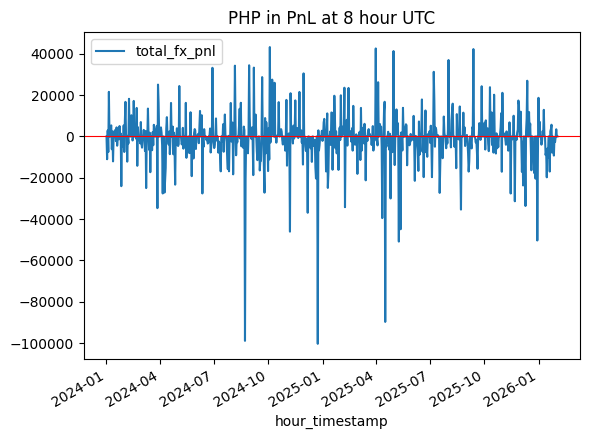

In [255]:
pnl_plot(df, 'PHP', 8)

In [291]:
friday_df_close = filter_df(df, 4, 10)
monday_df_open = filter_df(df, 0, 0)

In [292]:
friday_df_close.tail()

,ccy,hour_timestamp,hour_position,rate_to_usd,rate_to_gbp,total_fx_pnl,usd_rate,gbp_rate,position_in_USD,position_in_GBP
94162,INR,2026-01-30 10:00:00,6.614143e+09,0.010871,0.007916,-33728.468243,91.985319,126.328023,7.190434e+07,5.235690e+07
94502,KRW,2026-01-30 10:00:00,2.373201e+09,0.000692,0.000504,1352.996309,1445.922499,1985.702939,1.641306e+06,1.195144e+06
95155,PHP,2026-01-30 10:00:00,1.041498e+09,0.016955,0.012346,2817.249783,58.978956,80.998550,1.765880e+07,1.285823e+07
94846,IDR,2026-01-30 10:00:00,2.010349e+11,0.000060,0.000043,-19269.346643,16778.523490,23041.474654,1.198168e+07,8.724914e+06
94685,THB,2026-01-30 10:00:00,7.292830e+08,0.031771,0.023134,26785.289104,31.475047,43.226233,2.317019e+07,1.687130e+07


In [290]:
# closing exposure on friday - opening exposure on monday, get the largest numbers
# closing pnl on friday - opening pnl on monday, get the largest pnl

In [301]:
friday_df_close

,ccy,hour_timestamp,hour_position,rate_to_usd,rate_to_gbp,total_fx_pnl,usd_rate,gbp_rate,position_in_USD,position_in_GBP,match_date
123586,PHP,2024-01-05 10:00:00,1.117804e+09,0.017994,0.014214,4287.894789,55.575007,70.352183,2.011344e+07,1.588870e+07,2024-01-08
123604,THB,2024-01-05 10:00:00,8.946247e+08,0.028806,0.022755,943.257781,34.714990,43.945806,2.577056e+07,2.035745e+07,2024-01-08
123603,VND,2024-01-05 10:00:00,-7.427459e+08,0.000041,0.000032,90.436507,24390.243902,30864.197531,-3.045258e+04,-2.406497e+04,2024-01-08
123597,MYR,2024-01-05 10:00:00,3.124566e+07,0.214811,0.169691,1322.927471,4.655255,5.893064,6.711911e+06,5.302107e+06,2024-01-08
123587,INR,2024-01-05 10:00:00,4.880788e+09,0.012024,0.009499,16979.727638,83.164924,105.278673,5.868806e+07,4.636065e+07,2024-01-08
...,...,...,...,...,...,...,...,...,...,...,...
94162,INR,2026-01-30 10:00:00,6.614143e+09,0.010871,0.007916,-33728.468243,91.985319,126.328023,7.190434e+07,5.235690e+07,2026-02-02
94502,KRW,2026-01-30 10:00:00,2.373201e+09,0.000692,0.000504,1352.996309,1445.922499,1985.702939,1.641306e+06,1.195144e+06,2026-02-02
95155,PHP,2026-01-30 10:00:00,1.041498e+09,0.016955,0.012346,2817.249783,58.978956,80.998550,1.765880e+07,1.285823e+07,2026-02-02
94846,IDR,2026-01-30 10:00:00,2.010349e+11,0.000060,0.000043,-19269.346643,16778.523490,23041.474654,1.198168e+07,8.724914e+06,2026-02-02


In [306]:
# comparing friday close to monday open

friday_df_close['match_date'] = (friday_df_close['hour_timestamp'] + pd.Timedelta(days=3)).dt.date
monday_df_open['match_date'] = monday_df_open['hour_timestamp'].dt.date

aligned_df = pd.merge(
    monday_df_open[['match_date', 'ccy', 'total_fx_pnl', 'position_in_USD']], 
    friday_df_close[['match_date', 'ccy', 'total_fx_pnl', 'position_in_USD']], 
    on=['match_date', 'ccy'], 
    suffixes=('_Mon', '_Fri')
)

aligned_df['abs_exposure_change'] = abs(aligned_df['position_in_USD_Fri'] - aligned_df['position_in_USD_Mon'])
aligned_df['pnl_change'] = aligned_df['total_fx_pnl_Fri'] - aligned_df['total_fx_pnl_Mon']
aligned_df.sort_values(by='abs_exposure_change', ascending=False).head()

,match_date,ccy,total_fx_pnl_Mon,position_in_USD_Mon,total_fx_pnl_Fri,position_in_USD_Fri,abs_exposure_change,pnl_change
750,2026-01-26,INR,8888.483584,-4.204459e+07,30084.116151,5.639136e+07,9.843595e+07,21195.632567
607,2025-09-01,INR,41196.473389,-4.660733e+07,3499.269369,4.731097e+07,9.391830e+07,-37697.204020
693,2025-12-01,INR,-4357.163199,-3.517753e+07,10777.231227,5.460541e+07,8.978294e+07,15134.394426
762,2026-02-02,INR,32300.412645,-1.641476e+07,-33728.468243,7.190434e+07,8.831910e+07,-66028.880888
432,2025-03-10,INR,-56311.362319,-3.645856e+07,33223.809155,4.968132e+07,8.613988e+07,89535.171474


In [307]:
aligned_df.pnl_change.mean()

1326.9348684876127